In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import os, glob
import h5py

import sys
sys.path.append('../../')
import analysis_utils as utils
utils.load_plotting_setting()

import calc_gas_collision_spectrum as calc_gas

In [28]:
import importlib
importlib.reload(utils)
importlib.reload(calc_gas)

<module 'calc_gas_collision_spectrum' from '/Users/yuhan/work/nanospheres/gas_collisiions/analysis_notebooks/sphere_20260215/../../calc_gas_collision_spectrum.py'>

In [111]:
_f = r'/Users/yuhan/work/nanospheres/gas_collisiions/data_processed/gas_recon/sphere_20260215_gas_recon_all.h5py'

with h5py.File(_f, 'r') as f:
    bins = np.arange(0, 2000, 25)
    bc   = f['recon_histograms']['bc'][:]

    gas_types = ['xenon', 'krypton', 'sf6', 'background']

    # Load all histograms sorted by pressure (high → low).
    # If both 'name' and 'name_1' exist, keep only 'name_1'.
    hhs = {}
    for gas in gas_types:
        grp = f['recon_histograms'][gas]
        datasets = [k for k in grp if not k.endswith('_nocal')]
        superseded = {d[:-2] for d in datasets if d.endswith('_1')}
        datasets = [d for d in datasets if d not in superseded]
        
        datasets.sort(key=lambda d: grp[d].attrs['pressure_mbar'], reverse=True)
        hhs[gas] = [(grp[d][:], grp[d + '_nocal'][:], grp[d].attrs['pressure_mbar']) for d in datasets]

In [112]:
hhs_bg = np.asarray([hhs['background'][i][1] for i in range(4)])
hhs_bg_wcal = np.asarray([hhs['background'][i][0] for i in range(4)])

hh_bg_avg, hh_bg_max, hh_bg_min = np.mean(hhs_bg, axis=0), np.max(hhs_bg, axis=0), np.min(hhs_bg, axis=0)
hh_bg_wcal_avg, hh_bg_wcal_max, hh_bg_wcal_min = np.mean(hhs_bg_wcal, axis=0), np.max(hhs_bg_wcal, axis=0), np.min(hhs_bg_wcal, axis=0)

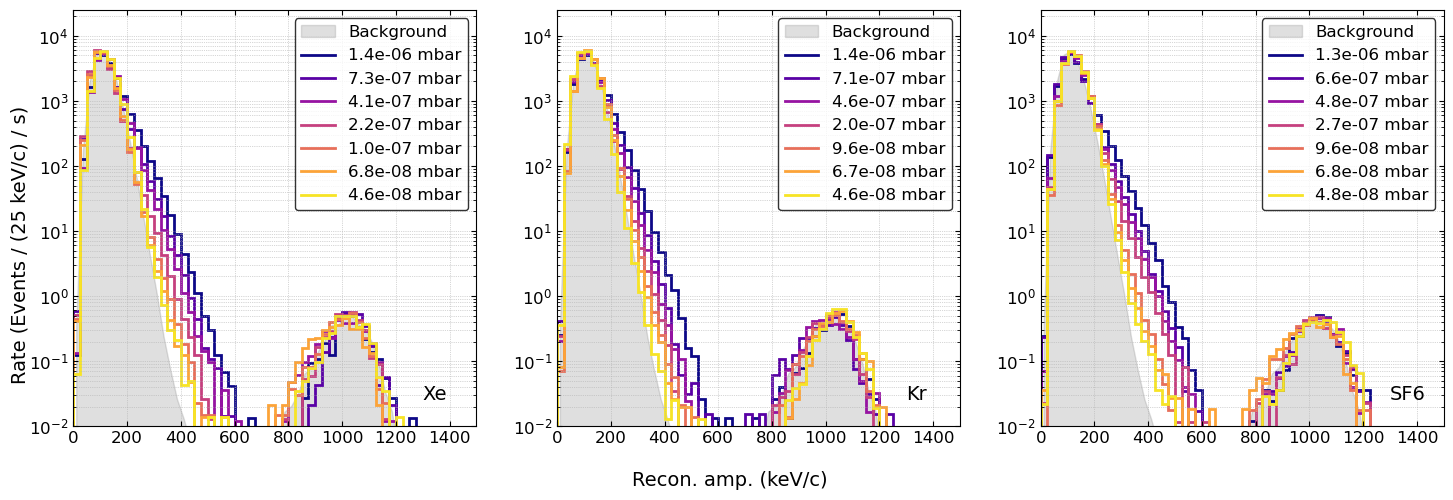

In [113]:
colors = plt.colormaps['plasma'](np.linspace(0, 0.95, 7))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, gas, label in zip(axes, ['xenon', 'krypton', 'sf6'], ['Xe', 'Kr', 'SF6']):
    ax.fill_between(bc, 0, hh_bg_wcal_avg/(50e-6*np.sum(hh_bg_wcal_avg)), color='gray', alpha=0.25, label='Background')

    for c, (hh, hh_nocal, p_mbar) in zip(colors, hhs[gas]):
        norm = 50e-6 * np.sum(hh)
        ax.stairs(hh/norm, edges=bins, color=c, linewidth=2, label=f'{p_mbar:.1e} mbar')

    ax.text(1300, 2.5e-2, label, fontsize=14)
    ax.set_yscale('log')
    ax.set_xlim(0, 1500)
    ax.set_ylim(1e-2, 2.5e4)
    ax.grid(which='both', ls=':', linewidth=0.5)
    ax.legend(edgecolor='k')

fig.supxlabel('Recon. amp. (keV/c)', fontsize=14)
fig.supylabel('Rate (Events / (25 keV/c) / s)', fontsize=14)
fig.tight_layout()


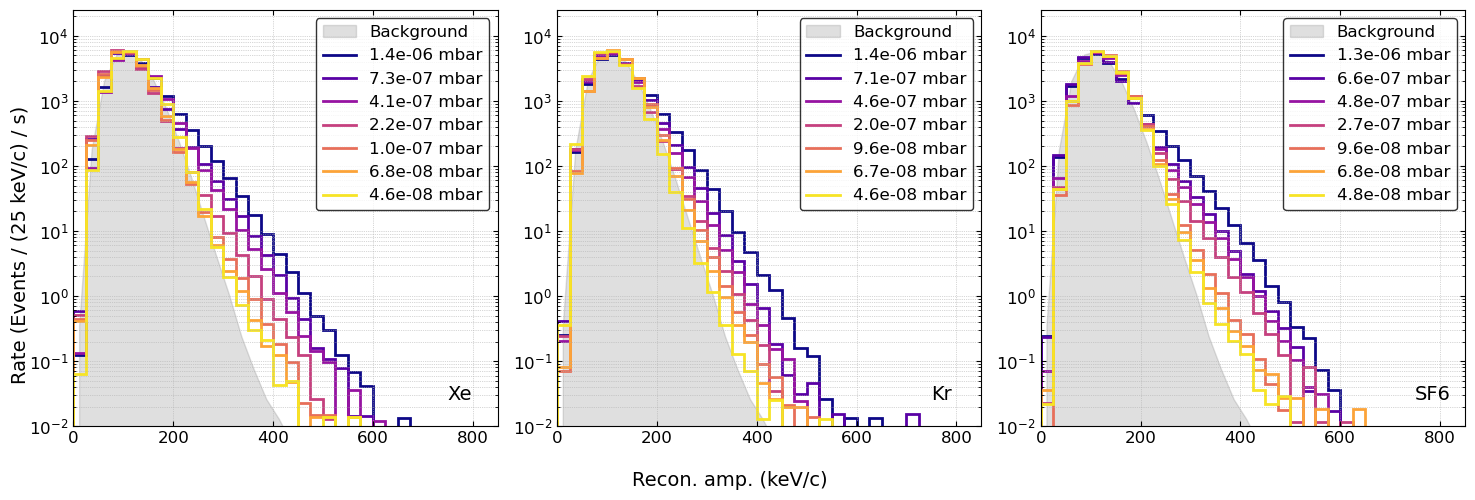

In [ ]:
colors = plt.colormaps['plasma'](np.linspace(0, 0.95, 7))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, gas, label in zip(axes, ['xenon', 'krypton', 'sf6'], ['Xe', 'Kr', 'SF6']):
    ax.fill_between(bc, 0, hh_bg_avg/(50e-6*np.sum(hh_bg_avg)), color='gray', alpha=0.25, label='Background')

    for c, (hh, hh_nocal, p_mbar) in zip(colors, hhs[gas]):
        norm = 50e-6 * np.sum(hh)
        ax.stairs(hh_nocal / norm, edges=bins, color=c, linewidth=2, linestyle='-', label=f'{p_mbar:.1e} mbar')

    ax.text(750, 2.5e-2, label, fontsize=14)
    ax.set_yscale('log')
    ax.set_xlim(0, 850)
    ax.set_ylim(1e-2, 2.5e4)
    ax.grid(which='both', ls=':', linewidth=0.5)
    ax.legend(edgecolor='k')

fig.supxlabel('Recon. amp. (keV/c)', fontsize=14)
fig.supylabel('Rate (Events / (25 keV/c) / s)', fontsize=14)
fig.tight_layout()
